In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import jax.numpy as jnp
import jax
import seaborn as sns

In [6]:
font = {'family' : 'serif',
 'serif' : ['Times New Roman'],
 # 'weight' : 'bold',
 'size' : 9
 }

mathtext = {"rm" : "serif",
 "it" : "serif:italic",
 "bf" : "serif:bold",
 "fontset": "custom",
}
mpl.rc('font', **font)
mpl.rc('mathtext', **mathtext)
mpl.rc('text', usetex='True')
mpl.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage[lining,semibold]{libertinus}\usepackage[libertine,vvarbb,amsthm]{newtxmath}\usepackage{bm}\usepackage{graphicx}\newcommand{\vsra}{{\ensuremath{\mathchoice{\includegraphics[height=1.1ex]{/Users/mhutchin/Documents/thesis/figures/symbols/veryshortrightarrow.pdf}}{\includegraphics[height=1.1ex]{/Users/mhutchin/Documents/thesis/figures/symbols/veryshortrightarrow.pdf}}{\includegraphics[height=.8ex]{/Users/mhutchin/Documents/thesis/figures/symbols/veryshortrightarrow.pdf}}{\includegraphics[height=.5ex]{/Users/mhutchin/Documents/thesis/figures/symbols/veryshortrightarrow.pdf}}}}}\newcommand{\vsla}{{\ensuremath{\mathchoice{\includegraphics[height=1.1ex]{/Users/mhutchin/Documents/thesis/figures/symbols/veryshortleftarrow.pdf}}{\includegraphics[height=1.1ex]{/Users/mhutchin/Documents/thesis/figures/symbols/veryshortleftarrow.pdf}}{\includegraphics[height=.8ex]{/Users/mhutchin/Documents/thesis/figures/symbols/veryshortleftarrow.pdf}}{\includegraphics[height=.5ex]{/Users/mhutchin/Documents/thesis/figures/symbols/veryshortleftarrow.pdf}}}}}')



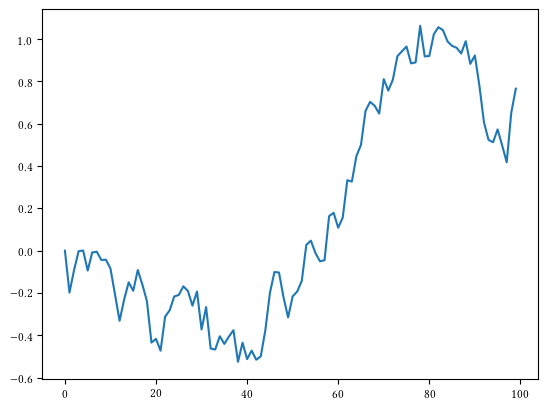

In [7]:
def sde_integrate(init, noise, gamma):
    def f(carry, noise):
        y = carry - gamma * 0.5 * carry + jnp.sqrt(gamma) * noise
        return y, carry

    return jax.lax.scan(f, init, noise)


n_steps = 100
gamma = 0.01
init = jnp.array([0.0])
noise = jax.random.normal(jax.random.PRNGKey(0), shape=(n_steps,))
path = sde_integrate(init, noise, gamma)[1]

plt.plot(path)

In [25]:
def kde_smooth(samples, x, bandwidth=0.01):
    dist = samples[None, :] - x[:, None]
    kernel = jnp.exp(-(dist**2) / bandwidth)
    smoothed = kernel.sum(axis=1)
    return smoothed / smoothed.sum()


def plot_kde_trajectory(
    samples,
    x,
    ax=None,
    cmap=sns.cubehelix_palette(
        light=1.0, dark=0.0, start=0.5, rot=-0.75, reverse=False, as_cmap=True
    ),
    bandwidth=0.1,
):

    x_min = x.min()
    x_max = x.max()

    nx = x.shape[0]

    kde_trajectory = jax.vmap(
        lambda samples, x: kde_smooth(samples, x, bandwidth=bandwidth),
        in_axes=(1, None),
    )(samples, x)

    if ax is None:
        plt.imshow(kde_trajectory.T, cmap=cmap, extent=(0, 1, x_min, x_max))
        aspect = ("auto",)
        ax = plt.gca()
    else:
        ax.imshow(
            kde_trajectory.T, cmap=cmap, aspect="auto", extent=(0, 1, x_min, x_max)
        )
        ax.plot(
            jnp.linspace(0, 1, samples.shape[1]),
            samples[:5].T,
            lw=0.5,
            color="k",
            alpha=0.2,
        )
        # ax.axhline(1)
        # ax.axhline(-1)
        # ax.set_axis_off()

(array([  136.,  1272.,  6609., 18274., 27610., 26290., 14614.,  4543.,
          610.,    42.]),
 array([-4.41909313, -3.50892782, -2.59876251, -1.6885972 , -0.77843189,
         0.13173342,  1.04189873,  1.95206404,  2.86222935,  3.77239513,
         4.68255997]),
 <BarContainer object of 10 artists>)

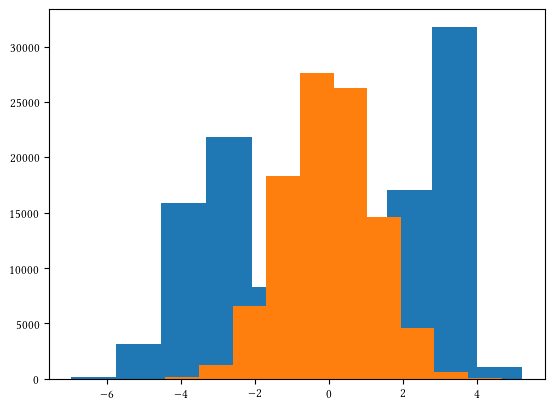

In [9]:
n_steps = 1000
n_point = 100000
gamma = 0.003

init = jnp.concat(
    [
        3
        + 0.5 * jax.random.normal(jax.random.PRNGKey(1), shape=(int(n_point * 0.5),)),
        -3
        + 1.0 * jax.random.normal(jax.random.PRNGKey(1), shape=(int(n_point * 0.5),)),
    ]
)

init = jax.random.permutation(jax.random.PRNGKey(0), init)

noise = jax.random.normal(jax.random.PRNGKey(0), shape=(init.shape[0], n_steps))

final, paths = jax.vmap(sde_integrate, in_axes=(0, 0, None))(init, noise, gamma)


plt.hist(init)
plt.hist(final)

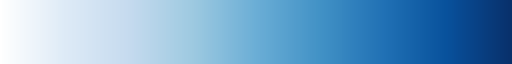

In [13]:
_Blues_data = (
    (1.0,  1.0,  1.0                ),
    (0.87058823529411766,  0.92156862745098034,  0.96862745098039216),
    (0.77647058823529413,  0.85882352941176465,  0.93725490196078431),
    (0.61960784313725492,  0.792156862745098  ,  0.88235294117647056),
    (0.41960784313725491,  0.68235294117647061,  0.83921568627450982),
    (0.25882352941176473,  0.5725490196078431 ,  0.77647058823529413),
    (0.12941176470588237,  0.44313725490196076,  0.70980392156862748),
    (0.03137254901960784,  0.31764705882352939,  0.61176470588235299),
    (0.03137254901960784,  0.18823529411764706,  0.41960784313725491)
)

blues_modified = mpl.colors.LinearSegmentedColormap.from_list(
    "BluesModified",
    _Blues_data,
    256
)
blues_modified

/var/folders/cc/xj6r755j6r9142bf7j9450tc010dc7/T/ipykernel_36053/1446392581.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


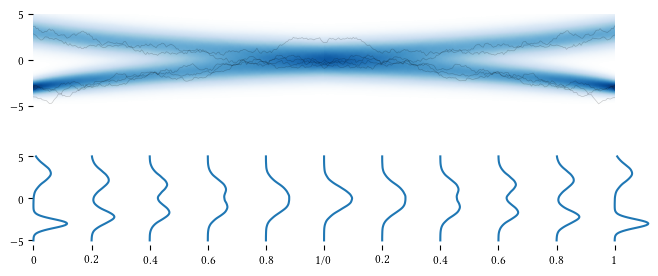

In [29]:
fig, axes  = plt.subplots(
    ncols=2,
    nrows=2,
    figsize=(7.5, 3),
    sharex=False,
    gridspec_kw=dict(
        height_ratios=[1,1], 
        width_ratios=[1,1],
        wspace=0,
        hspace=.5,
    )
)

x = jnp.linspace(-5, 5, 100)


pts = [
    kde_smooth(paths[:, i], x=x, bandwidth=0.05)
    for i in [0, 200, 400, 600, 800, 1000]
]
npts = len(pts)
# p0 = kde_smooth(paths[:, 0], x=x, bandwidth=0.05)
# pT = kde_smooth(paths[:, -1], x=x, bandwidth=0.05)


plot_kde_trajectory(
    paths[::1, ::5], x=x,
    ax=axes[0][0],
    cmap=blues_modified,
    bandwidth=0.05
)
plot_kde_trajectory(
    paths[::1, ::-5], x=x,
    ax=axes[0][1],
    cmap=blues_modified, bandwidth=0.05
)
# axes[0][0].plot(-p0, -x)
# axes[0][0].set_axis_off()
# axes[0][2].plot(-pT, -x)
# axes[0][2].set_axis_off()

axis_locs = [
    (i/(npts-1) + 0.01)*0.85 for i in range(npts)
]

axis_locs = [
    i/(npts-1) for i in range(npts)
]

for i in range(npts-1):
    axes[1][0].plot(
        3*pts[i] + axis_locs[i], -x,
        color='tab:blue',
        clip_on=False,
    )

for i in range(npts):
    axes[1][1].plot(
        3*pts[npts-i-1] + axis_locs[i], -x,
        color='tab:blue',
        clip_on=False,
    )


def tidy_axis(ax):
    pass
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    # ax.get_yaxis().set_ticks([])

tidy_axis(axes[0][0])
tidy_axis(axes[0][1])
tidy_axis(axes[1][0])
tidy_axis(axes[1][1])

# axes[1][0].set_axis_off()
# axes[1][1].set_axis_off()
axes[0][0].set_xlim([0, 1])
axes[0][1].set_xlim([0, 1])
axes[1][0].set_xlim([0, 1])
axes[1][1].set_xlim([0, 1])

axes[1][0].set_xticks(
    ticks=jnp.array([0, 0.2, 0.4, 0.6, 0.8, 1.0]),
    labels=["0", "0.2", "0.4", "0.6", "0.8", "1/0"]
)
axes[1][1].set_xticks(
    ticks=jnp.array([0.2, 0.4, 0.6, 0.8, 1.0]),
    labels=["0.2", "0.4", "0.6", "0.8", "1"]
)
axes[1][1].set_yticks([])
axes[0][1].set_yticks([])

axes[0][0].set_xticks([])
axes[0][1].set_xticks([])

plt.tight_layout()
plt.savefig('/Users/mhutchin/Documents/thesis/figures/diagrams/diffusion_model.pdf', bbox_inches='tight')
